# **Proyecto Integrador: Avance 4. Modelos alternativos**  

## **Integrantes**
Ana Cristina Torres Cordero | A00831285  
Irene Plascencia Villalobos | A01625258  
Jorge Santana Mendoza | A01376306  

### **Fecha de entrega:** 31 de Mayo del 2026

# **Contexto**

## **Problemática**
Los sistemas actuales de visión computacional para conteo de productos suelen estar diseñados para detectar objetos visibles. En escenarios de anaqueles con profundidad y apilamiento, esta formulación resulta insuficiente, ya que algunos productos pueden estar total o parcialmente ocultos por otros objetos, pero su existencia puede inferirse por continuidad estructural, repetición del patrón de acomodo, estimación de profundidad o geometría del stack.  
El problema central consiste en estimar el conteo amodal de productos en anaqueles cuando el conteo visible no coincide con el conteo real. El proyecto se enfoca en oclusiones estructurales derivadas de dos fenómenos principales: profundidad del anaquel y stacking de productos.  
Se busca desarrollar y evaluar una propuesta metodológica de visión computacional capaz de estimar el número total de productos en escenas de anaquel con oclusión estructural por profundidad y apilamiento. La propuesta deberá **integrar detección visible, estimación de profundidad y razonamiento espacial para inferir productos ocultos o parcialmente visibles** dentro de estructuras repetitivas de acomodo.

## **Objetivo del proyecto**  
Desarrollar y evaluar una propuesta de sistema de visión computacional basada en aprendizaje profundo para el conteo automático de productos en anaqueles bajo condiciones de oclusión, considerando una ruta progresiva desde el conteo visible hasta escenarios de conteo amodal e inferencia estructural.

# **AVANCES DATASET PROPIO**

**DATASET SIN ETIQUETAR:** https://drive.google.com/drive/folders/1Yn3DUbqbZ05xbffM_CMo2Dm8nLetZkJI?usp=drive_link

**Construcción del Dataset utilizando Roboflow**

Con el objetivo de contar con un conjunto de datos adecuado para el desarrollo y validación del sistema de conteo amodal, se utilizó la plataforma Roboflow para gestionar el proceso de anotación y preparación de imágenes.

Inicialmente, creamos un proyecto de detección de objetos dentro de Roboflow y se cargaron las imágenes correspondientes a diferentes configuraciones de productos colocados sobre anaqueles. Estas imágenes contienen diversos niveles de oclusión parcial, apilamiento y variaciones de posición, permitiendo representar escenarios similares a los encontrados en aplicaciones reales de inventario y retail.

Seguido de esto, realizamos la anotación manual de aproximadamente 57 imágenes donde pre-cargamos las clases que tenemos.




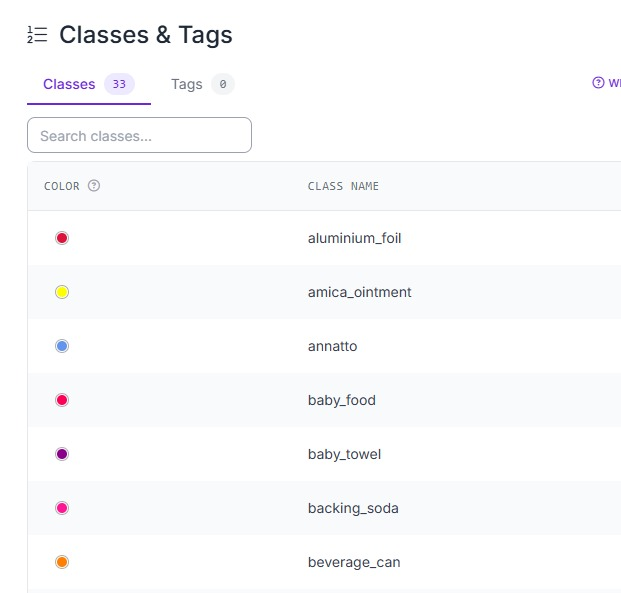

Nuestra anotación manual se ve de esta forma:

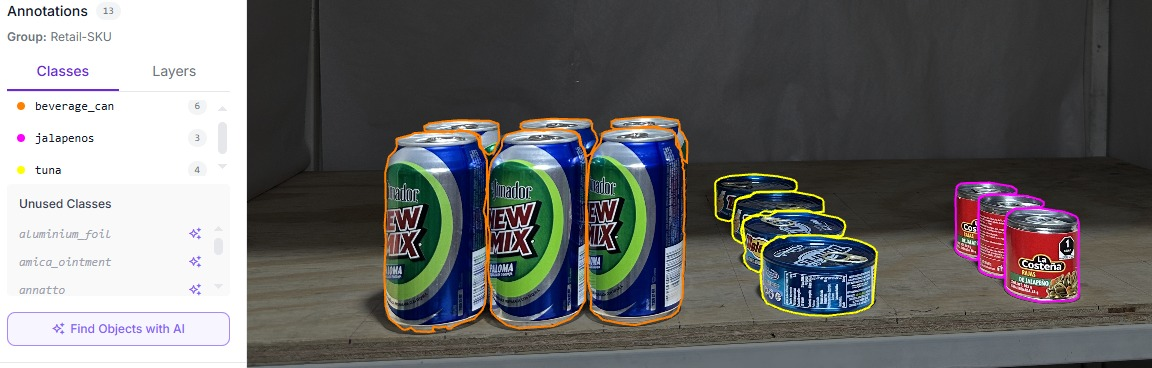

En esta etapa se dibujaron manualmente las cajas delimitadoras (bounding boxes) correspondientes a cada producto visible dentro de los anaqueles. Estas anotaciones constituyeron el conjunto inicial de datos etiquetados y sirvieron como referencia para entrenar un modelo preliminar de detección.

Una vez completado el etiquetado manual, se generó una primera versión del dataset y se entrenó un modelo de detección dentro de la plataforma Roboflow. El objetivo de este entrenamiento inicial fue obtener un modelo capaz de reconocer automáticamente los productos presentes en nuevas imágenes.

Posteriormente, dicho modelo fue utilizado mediante la herramienta Auto Label de Roboflow para generar anotaciones automáticas sobre el resto de las imágenes disponibles. Esta estrategia permitió acelerar significativamente el proceso de etiquetado, reduciendo la cantidad de trabajo manual requerido para la construcción del conjunto de datos completo.

A pesar de que la herramienta auto label de Roboflow permitió acelerar considerablemente el proceso de anotación, los resultados obtenidos no alcanzaron el nivel de precisión esperado en todos los casos. Durante la revisión de las etiquetas generadas automáticamente se observaron productos sin detectar y anotaciones incompletas, especialmente en escenarios con oclusiones, apilamientos o productos visualmente similares.

Consideramos que esta limitación está directamente relacionada con el tamaño reducido del conjunto de entrenamiento inicial utilizado para generar el modelo de autoetiquetado. Debido a restricciones de tiempo, únicamente se realizaron anotaciones manuales sobre 57 imágenes, cantidad que por lo visto no es suficiente para capturar toda la variabilidad presente en el conjunto de datos.

Sin embargo, los resultados obtenidos fueron suficientes para demostrar que el uso de roboflow es de suma utilidad. Se espera que, al incrementar progresivamente el número de imágenes etiquetadas manualmente, el modelo de detección mejore su capacidad de generalización y, en consecuencia, aumente significativamente la calidad de las anotaciones generadas mediante auto label.

Como trabajo futuro, se propone ampliar el dataset manualmente etiquetado y realizar nuevas iteraciones de autoetiquetado. Este proceso iterativo permitiría obtener anotaciones cada vez más precisas, reduciendo gradualmente la necesidad de correcciones manuales y acercándose al nivel de calidad requerido para aplicaciones de conteo amodal.

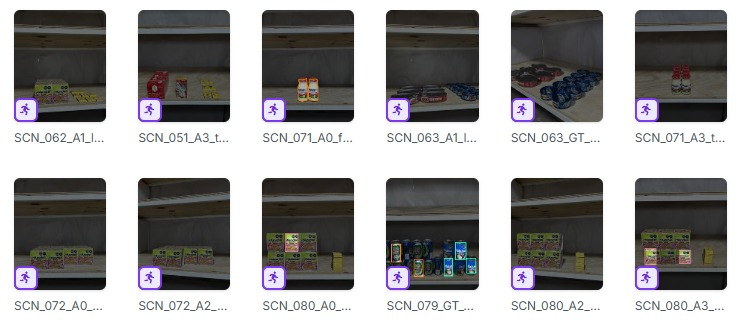

# **PRUEBA YOLO CON SKU-110K**
Debido a que nuestro dataset ya se encuentra creado pero aún estamos consolidando la parte del etiquetado, seguimos utilizando como prueba el dataset de SKU-110K. Y como parte del proceso de prueba de diferentes soluciones para el conteo amodal añadimos algunas alternativas que nos parecieron que pueden sumar a una solución final.

## 1. Conectar con drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Instalar YOLO

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00


## 3. Importar las librerías a utilizar

In [ ]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Entrenar modelo YOLO con SKU-110K

In [ ]:
#Carga YOLO
model = YOLO("yolov8n.pt")

#Entrenamiento de prueba con dataset de anaqueles
results = model.train(
    data="SKU-110K.yaml",   #Dataset retail
    epochs=10,              #Prueba rápida
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/producto_amodal/runs",
    name="prueba_sku110k"
)

print("Entrenamiento con SKU-110K terminado")

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SKU-110K.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=prueba_sku110k-9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## 5. Cargar el mejor modelo entrenado

In [ ]:
best_model_path = "/content/drive/MyDrive/producto_amodal/runs/prueba_sku110k-2/weights/best.pt"
model = YOLO(best_model_path)
print("Modelo SKU-110K cargado correctamente")

Modelo SKU-110K cargado correctamente


## 6. Validar Modelo

In [ ]:
#Evalúa el modelo usando imágenes de test
metrics = model.val(
    data="SKU-110K.yaml", #Dataset YAML
    split="val" #Utilizar split de prueba
)

print(metrics)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4469.0±172.3 MB/s, size: 1181.6 KB)
val: Scanning /content/datasets/SKU-110K/labels.cache... 588 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 588/588 274.0Mit/s 0.0s
val: /content/datasets/SKU-110K/images/val_0.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_115.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_127.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_166.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_172.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_190.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_2.jpg: corrupt JPEG restored and saved
val: /content/dat

## 7. Hacer predicciones

In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/Pruebas Avance 3 Proyecto Integrador/Prueba.jpg",
    save=True,
    conf=0.25,
    name="prediccion_retail",
    exist_ok=True,

    show_labels=False, #NO mostrar nombres/clases
    show_conf=False, #NO mostrar confidence
    line_width=3 #Grosor
)



image 1/1 /content/drive/MyDrive/Pruebas Avance 3 Proyecto Integrador/Prueba.jpg: 512x640 8 objects, 60.4ms
Speed: 3.1ms preprocess, 60.4ms inference, 1.8ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/prediccion_retail


## 8. Mostrar imagen con boxes

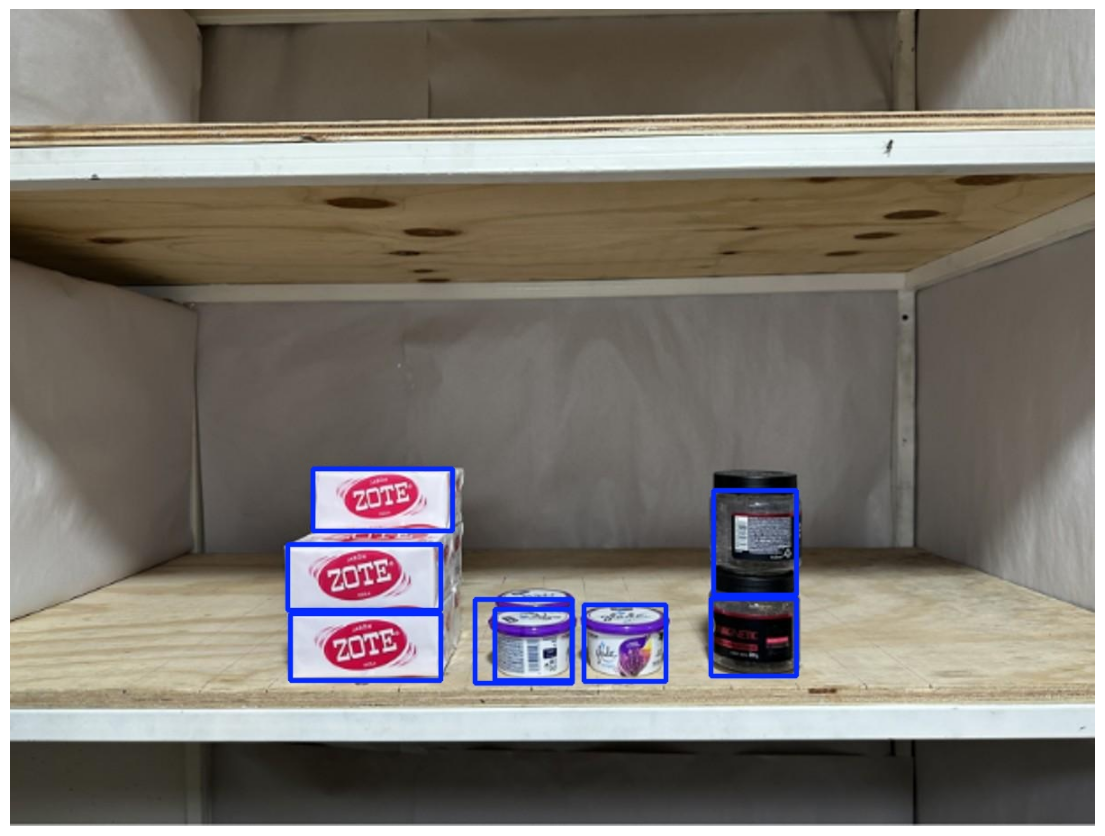

In [ ]:
img_path = Path("runs/detect/prediccion_retail/Prueba.jpg")
img = Image.open(img_path)

plt.figure(figsize=(14,14))
plt.imshow(img)
plt.axis("off")
plt.show()

## 9. Contar productos

In [ ]:
#Toma el primer resultado
result = results[0]
boxes = result.boxes

#Cuenta cuántas cajas detectó YOLO
visible_count = len(result.boxes)

print("Productos/objetos detectados:", visible_count)

Productos/objetos detectados: 8


# **YOLO + Inferencia de productos con detección de esquinas y espacios**

# Extraer bounding boxes

In [ ]:
detections = []

#Recorremos cada bounding box que detecto YOLO previamente
for box in boxes:
    #Coordenadas
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy() #Extracción de las cordenadas de la caja
    cx = (x1 + x2) / 2 #Calculo del centro de la caja
    cy = (y1 + y2) / 2 #Calculo del centro de la caja
    w = x2 - x1 #Ancho de la caja
    h = y2 - y1 #Alto de la caja
    #Guardamos la información
    detections.append({
        "bbox": [x1, y1, x2, y2],
        "center": [cx, cy],
        "w": w,
        "h": h
    })

#Conteo visible usando la lista procesada
visible_count = len(detections)

# Agrupar detecciones por filas

In [ ]:
def group_by_rows(detections, row_threshold=40):
    rows = [] #Aquí se almacenaran las filas que se encuenten
    detections_sorted = sorted(detections, key=lambda d: d["center"][1]) #Ordenar productos de arriba hacia abajo (Usando coordenada Y del centro)

    #Procesamos cada producto detectado
    for det in detections_sorted:
        cx, cy = det["center"]
        assigned = False #Indica si el producto ya fue asignado a alguna fila

        #Comparar contra todas la filas creadas
        for row in rows:
            row_y = np.mean([d["center"][1] for d in row]) #Altura promedio de la fila

            #Si se detecta una altura similar, se agrega a la fila
            if abs(cy - row_y) < row_threshold:
                row.append(det)
                assigned = True
                break
        #Si no coincide con otra altura, crea una nueva fila
        if not assigned:
            rows.append([det])

    return rows
#Ejecutar agrupación de productos por filas
rows = group_by_rows(detections, row_threshold=40)

# Detectar esquinas como evidencia visual

Es posible que un producto parcialmente oculto deje evidencia visual en forma de esquinas aun cuando YOLO no lo detecte.Para evitar detectar esquinas dentro de productos ya
reconocidos, se construye una máscara que únicamente permite buscar en regiones vecinas a las detecciones. Este proceso lo realizamos a través del algoritmo goodFeaturesToTrack.

In [ ]:
img = cv2.imread(img_path) #Imagen original
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #Imagen a escala de grises
mask = np.zeros(gray.shape, dtype=np.uint8) #Mascara inicial vacia

#Construir regiones de interés al rededor de cada producto
for det in detections:
    orig_x1, orig_y1, orig_x2, orig_y2 = map(int, det["bbox"]) #BBox detectada con YOLO

    #Tratamos de apliar un poco la región de busqueda para considerar laz zonas cercanas al producto
    pad_x = int(det["w"] * 0.3)
    pad_y = int(det["h"] * 0.1)

    x1 = max(0, orig_x1 - pad_x)
    y1 = max(0, orig_y1 - pad_y)

    x2 = min(gray.shape[1], orig_x2 + pad_x)
    y2 = min(gray.shape[0], orig_y2 + pad_y)

    #Buscar cerca de productos
    mask[y1:y2, x1:x2] = 255

    #Excluimos dentro de los productos detectados
    mask[orig_y1:orig_y2, orig_x1:orig_x2] = 0

#Detección de esquinas importantes usando Shi-Tomasi
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=500,#Maximo número de esquinas
    qualityLevel=0.01, #Calidad mínima aceptada
    minDistance=8, #Separacion minima entre esquinas
    mask=mask #Busqueda limitada por máscara
)

corner_points = [] #Aquí alamcenamos las esquinas encontradas

#Convertimos las esquinas detectadas a coordenadas
if corners is not None:
    for c in corners:
        x, y = c.ravel()
        corner_points.append((x, y))

# Máscara construida en el punto anterior



*   **Negro:** Zonas donde no se buscara evidencia (ya se porque sea parte del anaquel o ya este dentro de zonas detectadas.
*   **Blanco:** Zonas donde se buscaran esquinas o evidencia visual


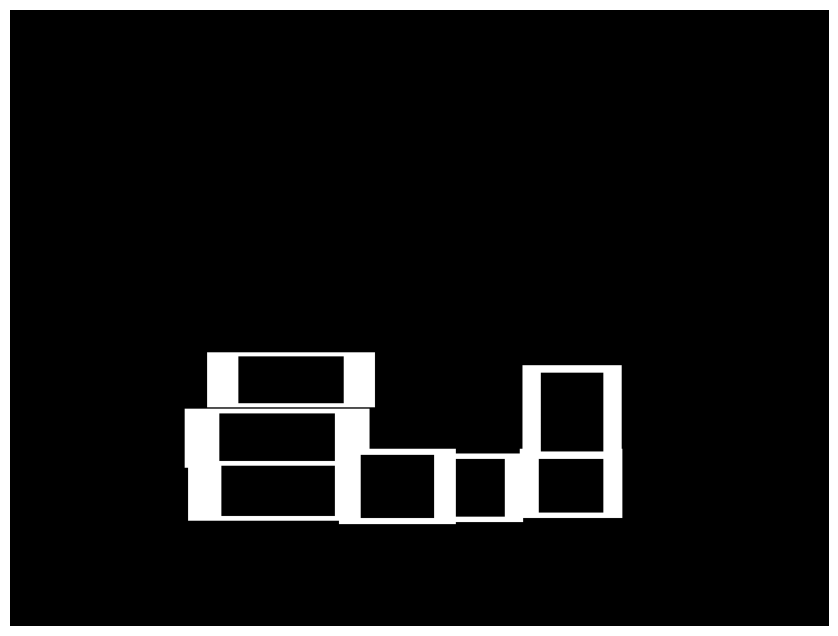

In [ ]:
plt.figure(figsize=(12,8))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

Aquí determinamos si una esquina detectada pertenece al interior de un producto ya identificado por YOLO.

El objetivo en esta sección es descartar esquinas generadas por las etiquetas de texto de los productos que ya vimos y conservar solo evidencia cercana a los bordes o fuera de las detecciones existentes, donde se encuentran los productos parcialmente ocultos.

In [ ]:
def is_inside_yolo_box_but_not_edge(x, y, detections, edge_margin=20):
    #Revisamos cada producto detectado con YOLO
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]

        #Verificar si la esquina esta dentro de la BBox
        if x1 <= x <= x2 and y1 <= y <= y2:
            near_left_edge = abs(x - x1) < edge_margin #Proximidad al borde izquierdo
            near_right_edge = abs(x - x2) < edge_margin #Proximidad al borde derecho

            #Si está cerca de los bordes no la detectamos como esquina interna
            if near_left_edge or near_right_edge:
               return False
            return True
    return False

# Inferir productos ocultos

Aquí analizamos la distribución espacial de los productos detectados en cada fila para identificar huecos muy grandes entre objetos consecutivos. Si se detecta un espacio mayor al esperado, se genera una hipótesis de producto oculto de dicha ubicación.

Posteriormente, validamos la sospecha de producto oculto utilizando la evidencia visual obtenida mediante detección de esquinas. Únicamente se confirma el producto si hay suficiente cantidad de esquinas detectadas.

In [ ]:
missing_products = [] #Productos ocultos encontrados
hidden_count = 0 #Conteo de productos inferidos
inferred_boxes = [] #Cuarda las BBox de produtos amodales aceptados

#Se analiza cada fila de productos por separado
for row_idx, row in enumerate(rows):
    row = sorted(row, key=lambda d: d["center"][0]) #Ordenamos productos de la fila de izquierda a derecha

    if len(row) < 2: #Si la fila tiene menos de 2 productos no puede haber hueco entre ellos
        continue

    #Se calcula el ancho y alto promedio de los productos en la fila
    avg_width = np.mean([d["w"] for d in row])
    avg_h = np.mean([d["h"] for d in row])

    #Comparamos cada producto con el siguiente dentro de la misma fila
    for i in range(len(row) - 1):
        #Producto actual y el que sigue
        current = row[i]
        next_det = row[i + 1]
        #Coordenada X del centro de ambos productos
        x_current = current["center"][0]
        x_next = next_det["center"][0]
        #Gap entre loss centros
        gap = x_next - x_current
        #Separación esperada entre productos consecutivos (ancho promedio como referencia)
        expected_gap = avg_width

        # Detectar hueco grande
        if gap > expected_gap * 1.8:
          #Estimamos cuantos productos podrían caber en ese hueco
          estimated_missing = round(gap / expected_gap) - 1
          estimated_missing = max(0, estimated_missing)

          #Analizamos si hay esquinas que se alcancen a distinguir en dichos huecos
          for k in range(estimated_missing):
            amodal_w = avg_width*0.7 #Ancho de la BBox amodal
            amodal_h = avg_h*1.0 #Alto de la BBox amodal
            inferred_cx = x_current + (k + 1) * expected_gap #Centro del producto oculto

            #Coordenadas de la nueva BBox inferida
            box_x1 = inferred_cx - amodal_w / 2
            box_y1 = current["center"][1] - amodal_h / 2
            box_x2 = inferred_cx + amodal_w / 2
            box_y2 = current["center"][1] + amodal_h / 2

            #Buscar esquinas SOLO dentro de esta caja inferida
            corners_in_box = []
            #Revisamos las esquinas detectadas previamente
            for cx_corner, cy_corner in corner_points:
              #Verificamos si la esquina está dentro de la caja nueva
              if box_x1 < cx_corner < box_x2 and box_y1 < cy_corner < box_y2:
                #Descartamos esquinas que pertenecen al interior de productos ya detectados
                if not is_inside_yolo_box_but_not_edge (cx_corner,cy_corner,detections):
                  corners_in_box.append((cx_corner, cy_corner))

            #Si esta caja específica no tiene evidencia, no se acepta
            if len(corners_in_box) < 10:
              continue

            #Si pasa el filtro anterior, se acepta como producto amodal inferido
            inferred_box = {
               "x1": box_x1,
               "y1": box_y1,
               "x2": box_x2,
               "y2": box_y2,
                "corners": len(corners_in_box),
                "corner_points": corners_in_box
                    }

            inferred_boxes.append(inferred_box) #Caja amodal aceptada
            hidden_count += 1 #Se va aumentando el conteo de productos ocultos

            #Detalles de la inferencia
            missing_products.append({
                "row": row_idx,
                "between_detection": (i, i + 1),
                "estimated_missing": 1,
                "gap": gap,
                "corners_in_box": len(corners_in_box)

             })


# Conteo amodal

In [ ]:
amodal_count = visible_count + hidden_count #Suma el conteo visible con el inferido

#Resultados
print("Productos visibles detectados:", visible_count)
print("Productos inferidos/ocultos:", hidden_count)
print("Conteo amodal estimado:", amodal_count)
print("\nDetalles:")

#Detalles de los productos inferidos
for item in missing_products:
    print(item)

Productos visibles detectados: 8
Productos inferidos/ocultos: 1
Conteo amodal estimado: 9

Detalles:
{'row': 1, 'between_detection': (0, 1), 'estimated_missing': 1, 'gap': np.float32(434.44983), 'corners_in_box': 25}


# Visualización de detecciones de YOLO (AZUL)

In [ ]:
for det in detections:
    x1, y1, x2, y2 = map(int, det["bbox"]) #Obtenemos las coordenadas del BBox
    #Dibuja la caja azul
    cv2.rectangle(img,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

# Visualización de detecciones amodales (ROJO)

In [ ]:
#Obtenemos las coordenadas del BBox amodal inferido
for box in inferred_boxes:
    x1 = int(box["x1"])
    y1 = int(box["y1"])
    x2 = int(box["x2"])
    y2 = int(box["y2"])

    #Dibujamos el BBox amodal en rojo
    cv2.rectangle(img,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        4
    )
    #Etiquetamos la caja como detección amodal
    cv2.putText(img,
        "AMODAL",
        (x1, max(y1 - 10, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )


# Visualización de esquinas detectadas (AMARILLO)

In [ ]:
#Obtenemos las coordenadas de la esquina detectada
for box in inferred_boxes:
    #Dibujamos la esquina en amarillo
    for x, y in box["corner_points"]:
        cv2.circle(img,
            (int(x), int(y)),
            3,
            (0, 255, 255),
            -1
        )

# RESULTADO DE LA IMAGEN:

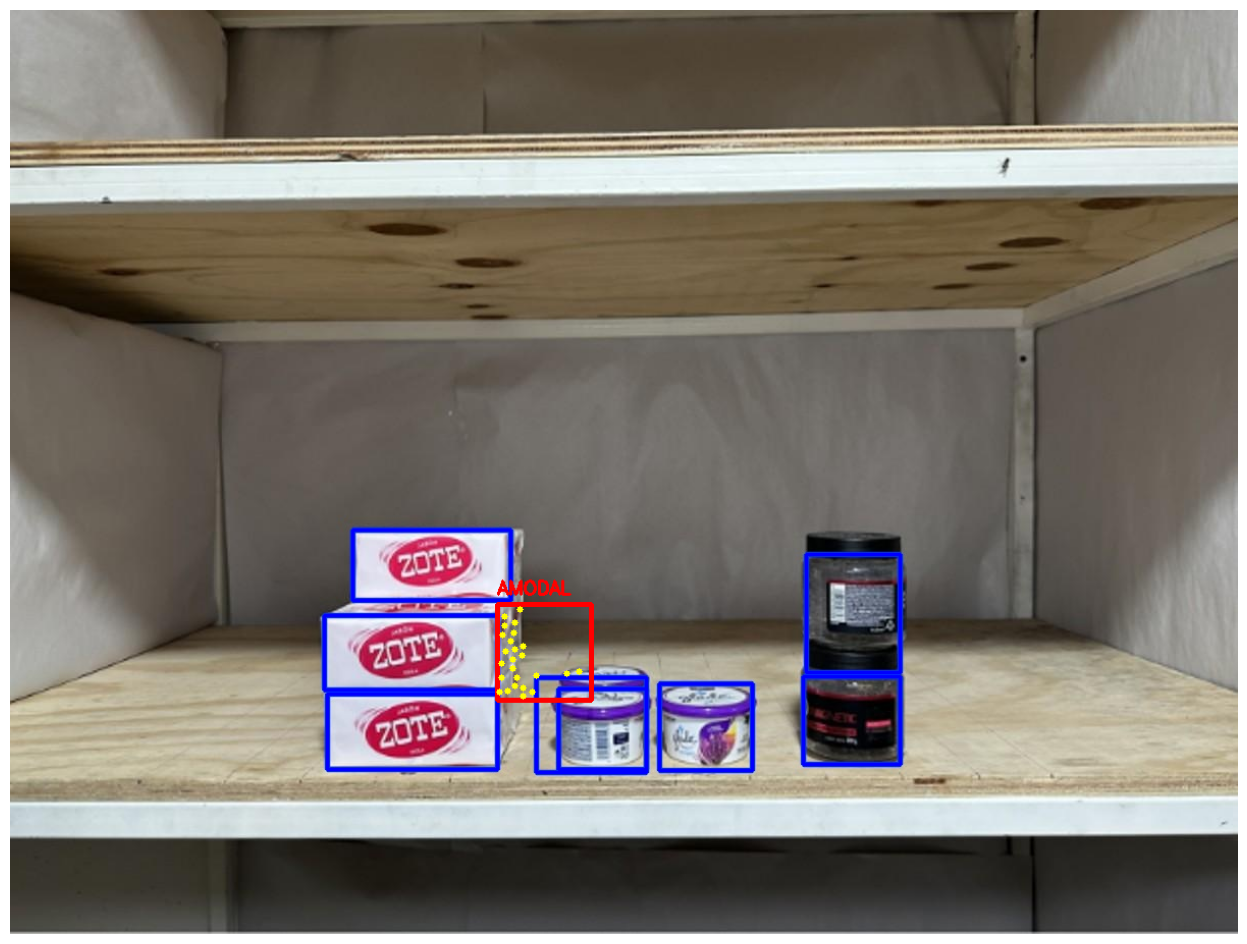

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 12))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()


# Observaciones:

El enfoque propuesto basado en YOLO y evidencia visual mediante detección de esquinas nos permitió identificar productos visibles y generar hipótesis de productos parcialmente ocultos. En la imagen mostrada, el algoritmo logró inferir correctamente la presencia de un posible producto detrás de los jabones, utilizando las esquinas detectadas como evidencia para validar la inferencia amodal.Es necesario tomar en cuenta que aunque si detecto presencia de producto ocluido en el lugar correcto, pero no contó acertadamente la cantidad.

Sin embargo, durante las pruebas se observó que el desempeño disminuye en productos con superficies homogéneas o etiquetas predominantemente blancas, ya que estos generan menos bordes y esquinas detectables. Asimismo, la calidad de la inferencia depende fuertemente de la detección de esquinas, lo que provoca dificultades cuando los productos presentan bajo contraste, iluminación variable o texturas poco definidas.

En general, los resultados demuestran la viabilidad de combinar detección de objetos con inferencia amodal basada en características visuales, pero existen oportunidades de mejora mediante otras técnicas que a continuación observaremos.

# **YOLO + Detección de bordes**

# Praparación previa

In [ ]:
#Preparación de imagen y detección de bordes
img = cv2.imread(img_path) #Imagen original
img_vis = img.copy() #Copia para dibujar los resultados
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #Imagen convertida a escala de grises
edges = cv2.Canny(gray, 80, 180) #Detección de bordes mediante Canny

#Estadísticas de las detecciones visibles
avg_w = np.mean([d["w"] for d in detections]) #Ancho promedio de los productos detectados
avg_h = np.mean([d["h"] for d in detections]) #Alto promedio de los productos detectados

#Variables necesarias
inferred_boxes = []
hidden_count = 0


# Evitar empalmes con las detecciones visibles

In [ ]:
def overlaps_visible(hx1, hy1, hx2, hy2, detections, threshold=0.35):
    #Revisar cada detección visible de YOLO
    for d in detections:
        x1v, y1v, x2v, y2v = map(int, d["bbox"]) #Coordenadas de la BBox

        #Calcular coordenadas del cruce entre la caja inferida y la caja visible
        ix1 = max(hx1, x1v)
        iy1 = max(hy1, y1v)
        ix2 = min(hx2, x2v)
        iy2 = min(hy2, y2v)

        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1) #Area de intersección
        area_hidden = max(1, (hx2 - hx1) * (hy2 - hy1)) #Area de la caja inferida

        #Si gran parte de la caja inferida cae dentro de una caja visible, se descarta
        if inter / area_hidden > threshold:
            return True

    return False

# Evitar duplicar inferencias amodales

In [ ]:
def overlaps_inferred(hx1, hy1, hx2, hy2, inferred_boxes, threshold=0.45):
    #Revisar cada caja amodal ya inferida
    for b in inferred_boxes:
        x1b, y1b, x2b, y2b = b["x1"], b["y1"], b["x2"], b["y2"] #Coordenadas de la Bbox amodal existente

        #Calcular coordenadas del cruce entre la nueva BBox y una BBix amodal previa
        ix1 = max(hx1, x1b)
        iy1 = max(hy1, y1b)
        ix2 = min(hx2, x2b)
        iy2 = min(hy2, y2b)

        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1) #Area de intersección
        area_hidden = max(1, (hx2 - hx1) * (hy2 - hy1)) #Area de la caja inferida

        #Si gran parte de la caja inferida cae dentro de una caja inferida ya existente, se descarta
        if inter / area_hidden > threshold:
            return True

    return False

# Límite para no inventar productos flotando muy arriba
shelf_limit_y = int(min([d["bbox"][1] for d in detections]) - 0.35 * avg_h)

# Inferencia de producto oculto en la parte superior

En esta sección se busca evidencia de productos parcialmente ocultos detrás de un producto visible, ya que suelen observarse en la parte de arriba del producto frontal

In [ ]:
for det in detections:
    #Obtener coordenadas y centro del producto visible
    x1, y1, x2, y2 = map(int, det["bbox"])
    cx, cy = det["center"]

    #Región de busqueda  arriba del producto visible
    back_x1 = int(x1 - 0.10 * avg_w)
    back_x2 = int(x2 + 0.10 * avg_w)
    back_y1 = int(y1 - 0.45 * avg_h)
    back_y2 = int(y1 + 0.15 * avg_h)
    #Ajuste de coordenadas para que no se salgan de la imagen
    back_x1 = max(0, back_x1)
    back_y1 = max(0, back_y1)
    back_x2 = min(img.shape[1], back_x2)
    back_y2 = min(img.shape[0], back_y2)

    roi_edges = edges[back_y1:back_y2, back_x1:back_x2] #Extraemos los bordes dentro de la región candidata
    edge_pixels = np.count_nonzero(roi_edges) #Calculo de pixeles de borde en la región
    roi_area = roi_edges.shape[0] * roi_edges.shape[1] #Área total de la región
    edge_density = edge_pixels / roi_area if roi_area > 0 else 0 #Densidad de los bordes

    #Definir el tamaño de la caja amodal inferida
    amodal_w = avg_w * 0.90
    amodal_h = avg_h * 0.90

    #Ponemos la caja inferida arriba del producto visible
    hidden_cx = cx
    hidden_cy = y1 - 0.15 * avg_h

    #Convertir el centro y tamaño a coordenadas de bounding box
    hx1 = int(hidden_cx - amodal_w / 2)
    hy1 = int(hidden_cy - amodal_h / 2)
    hx2 = int(hidden_cx + amodal_w / 2)
    hy2 = int(hidden_cy + amodal_h / 2)

    #Si la densidad de los bordes es baja, no se consideran
    if edge_density < 0.8:
        continue
    #Evitamos inferior productos muy arriba en el anaquel
    if hidden_cy < shelf_limit_y:
        continue
    #Evitar contar como oculto algo que ya está en la detección visible
    if overlaps_visible(hx1, hy1, hx2, hy2, detections, threshold=0.35):
        continue
    #Evita duplicar una inferencia ya aceptada
    if overlaps_inferred(hx1, hy1, hx2, hy2, inferred_boxes, threshold=0.45):
        continue

    #Si pasa todos los filtros acepta la nueva BBox
    inferred_boxes.append({
        "x1": hx1,
        "y1": hy1,
        "x2": hx2,
        "y2": hy2,
        "edge_density": edge_density,
        "type": "top_hidden"
    })

    hidden_count += 1 #Actualiza el conteo

    #Dibujamos en amarillo la región donde se buscó evidencia
    cv2.rectangle(img_vis, (back_x1, back_y1), (back_x2, back_y2), (0, 255, 255), 2)

# Inferencia de producto oculto en la parte lateral derecha

En esta sección se busca evidencia de productos parcialmente ocultos detrás de un producto visible, ya que si el ángulo de la cámara es diferente al frontal, la observación de las regiones laterales es importante.

In [ ]:
for det in detections:
    #Obtener coordenadas y centro del producto visible
    x1, y1, x2, y2 = map(int, det["bbox"])
    cx, cy = det["center"]
    #Calcular relación alto/ancho del producto (distinguir entre productos)
    aspect = det["w"] / det["h"]

    # Solo aplicar a productos anchos rectangulares
    if aspect < 1.35:
        continue

    #Definir región de búsqueda hacia el lado derecho del producto visible
    side_x1 = int(x2 - 0.10 * avg_w)
    side_x2 = int(x2 + 0.55 * avg_w)
    side_y1 = int(y1 + 0.05 * avg_h)
    side_y2 = int(y2 - 0.05 * avg_h)
    #Ajuste de coordenadas para que no se salgan de la imagen
    side_x1 = max(0, side_x1)
    side_y1 = max(0, side_y1)
    side_x2 = min(img.shape[1], side_x2)
    side_y2 = min(img.shape[0], side_y2)

    roi_edges = edges[side_y1:side_y2, side_x1:side_x2] #Extraemos los bordes dentro de la región candidata
    edge_pixels = np.count_nonzero(roi_edges) #Calculo de pixeles de borde en la región
    roi_area = roi_edges.shape[0] * roi_edges.shape[1] #Área total de la región
    edge_density = edge_pixels / roi_area if roi_area > 0 else 0 #Densidad de los bordes

    #Ponemos la caja inferida a la derecha del producto visible
    hidden_cx = x2 + 0.30 * avg_w
    hidden_cy = cy
    #Definir el tamaño de la caja amodal inferida
    amodal_w = avg_w * 0.90
    amodal_h = avg_h * 0.95

    #Convertir el centro y tamaño a coordenadas de bounding box
    hx1 = int(hidden_cx - amodal_w / 2)
    hy1 = int(hidden_cy - amodal_h / 2)
    hx2 = int(hidden_cx + amodal_w / 2)
    hy2 = int(hidden_cy + amodal_h / 2)

    #Si la densidad de los bordes es baja, no se consideran
    if edge_density < 0.08:
        continue
    #Evitar contar como oculto algo que ya está en la detección visible
    if overlaps_visible(hx1, hy1, hx2, hy2, detections, threshold=0.35):
        continue
    #Evita duplicar una inferencia ya aceptada
    if overlaps_inferred(hx1, hy1, hx2, hy2, inferred_boxes, threshold=0.45):
        continue

    #Si pasa todos los filtros acepta la nueva BBox
    inferred_boxes.append({
        "x1": hx1,
        "y1": hy1,
        "x2": hx2,
        "y2": hy2,
        "edge_density": edge_density,
        "type": "side_hidden"
    })

    hidden_count += 1 #Actualiza el conteo

    #Dibujamos en amarillo la región donde se buscó evidencia
    cv2.rectangle(img_vis, (side_x1, side_y1), (side_x2, side_y2), (0, 255, 255), 2)

# Dibujar los resultados obtenidos de YOLO (AZUL)

In [ ]:
# Detecciones visibles YOLO en azul
for det in detections:
    x1, y1, x2, y2 = map(int, det["bbox"])

    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(
        img_vis,
        "VISIBLE",
        (x1, max(y1 - 8, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2
    )

# Dibujar los resultados obtenidos de conteo amodal (ROJO)

In [ ]:
# Inferencias amodales
for box in inferred_boxes:
    x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]

    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 0, 255), 3)
    cv2.putText(
        img_vis,
        f"{box['type']} {box['edge_density']:.3f}",
        (x1, max(y1 - 8, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 0, 255),
        2
    )

# Resultados obtenidos

Productos visibles detectados: 8
Productos inferidos/ocultos: 1
Conteo amodal estimado: 9


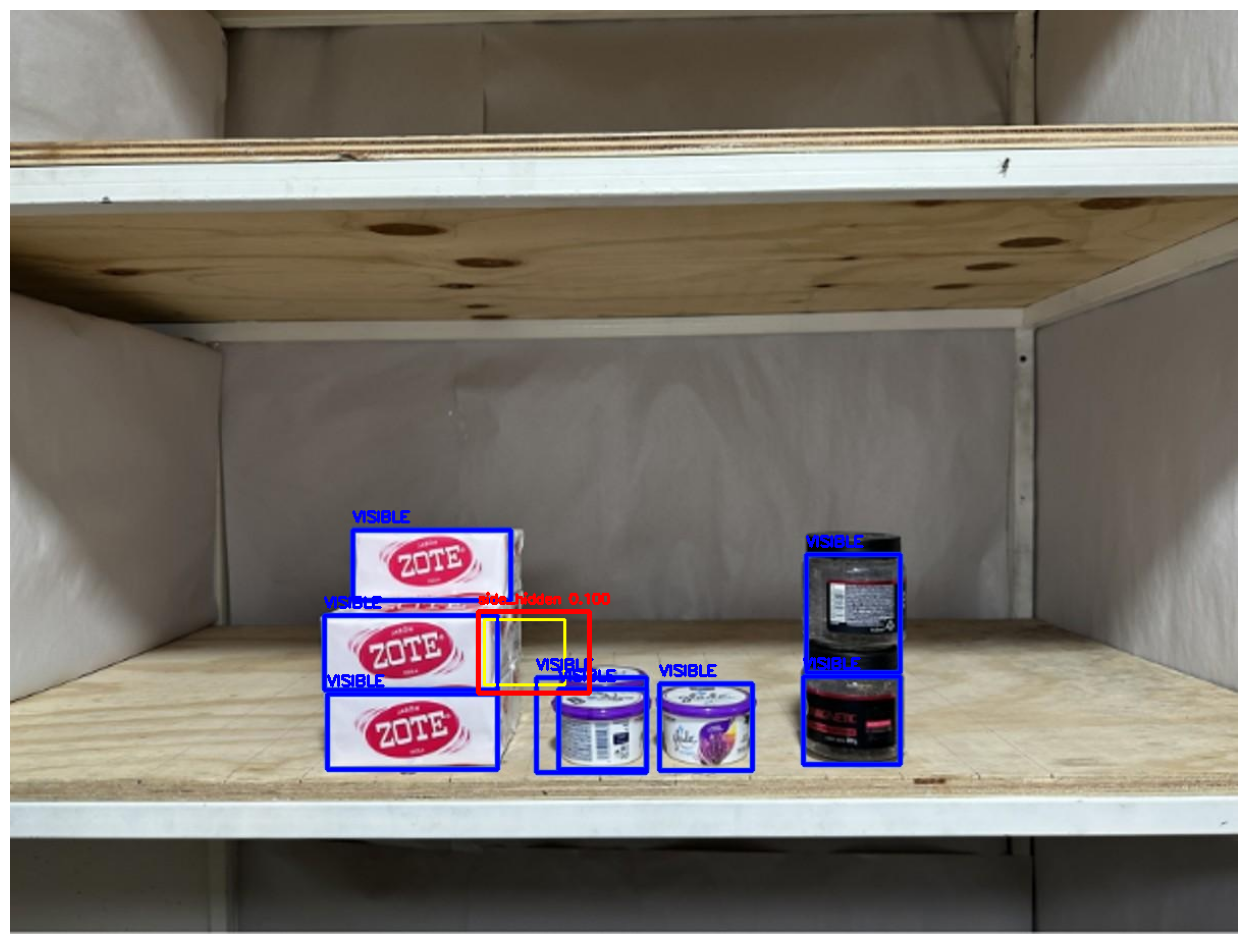

In [ ]:
amodal_count = visible_count + hidden_count

print("Productos visibles detectados:", visible_count)
print("Productos inferidos/ocultos:", hidden_count)
print("Conteo amodal estimado:", amodal_count)

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Mostrar la imágen con Canny enfocada a su uso específico

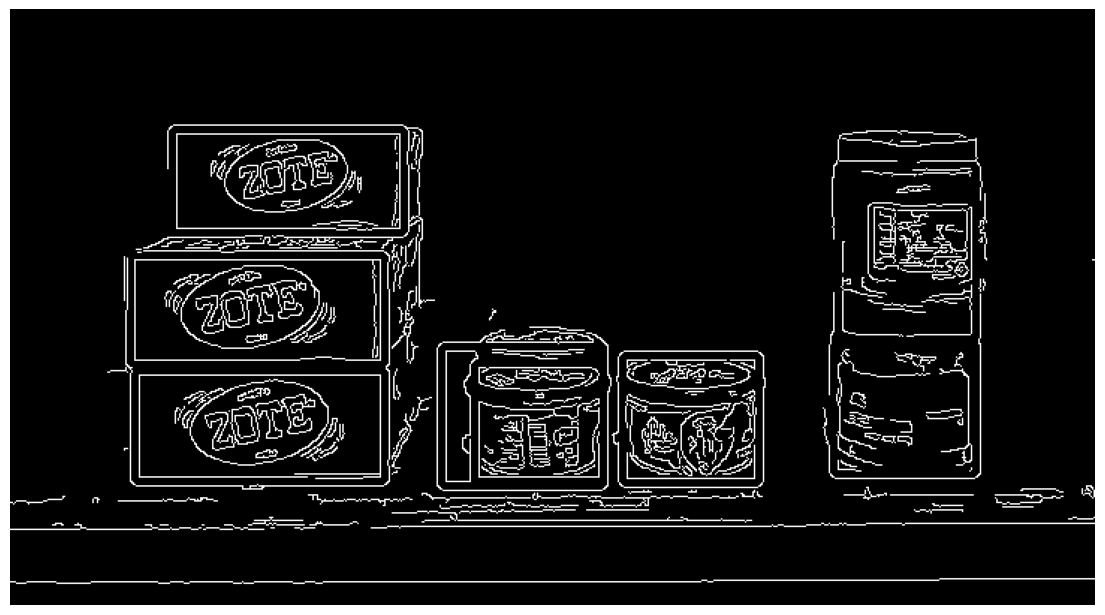

In [ ]:
#Obtener caja global que contiene todos los productos detectados

all_x1 = min([int(d["bbox"][0]) for d in detections])
all_y1 = min([int(d["bbox"][1]) for d in detections])

all_x2 = max([int(d["bbox"][2]) for d in detections])
all_y2 = max([int(d["bbox"][3]) for d in detections])

margin = 80

crop_x1 = max(0, all_x1 - margin)
crop_y1 = max(0, all_y1 - margin)

crop_x2 = min(edges.shape[1], all_x2 + margin)
crop_y2 = min(edges.shape[0], all_y2 + margin)

edges_crop = edges[crop_y1:crop_y2, crop_x1:crop_x2]

plt.figure(figsize=(14,8))
plt.imshow(edges_crop, cmap="gray")
plt.axis("off")
plt.show()

# Observaciones:

Esta estrategia propuesta utiliza la densidad de bordes detectados mediante Canny como evidencia visual para inferir la presencia de productos parcialmente ocultos detrás de objetos ya detectados por YOLO.

La técnica logró detectar correctamente un producto oculto detrás de las cajas de jabón, generando una inferencia amodal de acuerdo a la distribución observada en el anaquel. El uso de una región de interés localizada detrás del producto visible permitió reducir un poco los falsos positivos provenientes del fondo del estante y los filtros de empalme implementados evitaron que se generaran múltiples inferencias sobre el mismo producto oculto.

Algunas de las limitaciones que observamos son que el desempeño depende fuertemente de la presencia de bordes visibles en la zona ocluida,productos con etiquetas claras o superficies homogéneas (por ejemplo, empaques blancos o con poco contraste como en caso del jabón o latas de champiños) generan una densidad de bordes baja, dificultando su detección. Esta técnica presenta mejor desempeño en productos con formas rectangulares y bordes definidos, como cajas o empaques rígidos, pero en productos cilíndricos o de geometría compleja, la evidencia generada por Canny es menos consistente debido a la presencia de contornos curvos y menor cantidad de esquinas visibles.

Por lo tanto, esta implementación requiere de varias mejoras como extender la estrategia de inferencia lateral desarrollada para cajas hacia productos cilíndricos, utilizando regiones de búsqueda adaptadas a su geometría. También sería importante replicar la inferencia lateral actualmente aplicada al lado derecho de los productos detectados hacia el lado izquierdo, permitiendo detectar objetos ocultos en ambos sentidos y reduciendo la dependencia de la orientación de la oclusión.

Finalmente, los resultados obtenidos muestran que la detección basada en bordes constituye una fuente de evidencia útil para realizar inferencia amodal en escenarios de anaqueles. Sin embargo, la efectividad en este momento es mayor en productos de forma rectangular.